In [ ]:
import sys
import os
import re
import json
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import HTML, display
import html

import torch
from transformers import pipeline
from tqdm.auto import tqdm
from datasets import load_dataset

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the 'src' directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_prepared_splits
from src.utils import (
    build_ranking_specs,
    collect_token_indices_from_items,
    highlight_spans,
    make_json_serializable,
    mask_spans_in_text,
    predict_with_pipeline,
    rank_indices_by_score,
    save_aopc_outputs,
    select_top_fraction_indices,
    trim_char_span,
)

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataset and model
DATASET_NAME = "timonziegenbein/appropriateness-corpus"
MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"

# Columns
TEXT_COL = "post_text"
TEXT_NORM_COL = "text_norm"
LABEL_COL = "Inappropriateness"
ID_COL = "post_id"

# Class labels used by the Hugging Face classifier
APPROPRIATE_LABEL = "LABEL_0"
INAPPROPRIATE_LABEL = "LABEL_1"

# Inference settings
MAX_LENGTH = 512
BATCH_SIZE = 16

if torch.cuda.is_available():
    TORCH_DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    TORCH_DEVICE = torch.device("mps")
else:
    TORCH_DEVICE = torch.device("cpu")

DEVICE = TORCH_DEVICE

# Attention settings
ATTENTION_METHODS = ["last_cls", "rollout"]
QUANTILE_VALUES = [0.3, 0.4, 0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
WINDOW_SIZE_VALUES = [0, 1, 2, 3]

# Output
BASE_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = BASE_DIR / "attention_results"
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Attention cache settings
CACHE_DIR = OUTPUT_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DEV_ATTENTION_CACHE_PATH = CACHE_DIR / "attention_cache_dev_tp.json"
TEST_ATTENTION_CACHE_PATH = CACHE_DIR / "attention_cache_test_tp.json"

OVERWRITE_ATTENTION_CACHE = False

# AOPC evaluates ranking quality, not quantile/window-size config quality.
AOPC_FRACTIONS = [0.01, 0.05, 0.10, 0.20, 0.50]

# Minimal merging only for directly adjacent selected tokens.
# This is not a tuned window-size setting.
AOPC_WINDOW_SIZE = 0

# Random control runs.
AOPC_RANDOM_RUNS = 10
AOPC_RANDOM_SEED = SEED

AOPC_OUTPUT_DIR = OUTPUT_DIR / "aopc_ranking_evaluation"
AOPC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Cache dir:", CACHE_DIR)
print("AOPC fractions:", AOPC_FRACTIONS)
print("AOPC output dir:", AOPC_OUTPUT_DIR)

print("Pipeline device:", DEVICE)
print("Torch device:", TORCH_DEVICE)

In [4]:
pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=MAX_LENGTH
)

tokenizer = pipe.tokenizer
model = pipe.model
model.to(TORCH_DEVICE)
model.eval()

MASK_TOKEN = tokenizer.mask_token if tokenizer.mask_token is not None else "[MASK]"

print("Mask token:", MASK_TOKEN)
print("Model labels:", model.config.id2label)

Mask token: [MASK]
Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}


# Load prepared Data

In [ ]:
df_all, train_df, val_df, test_df = load_prepared_splits()

print("All:", df_all.shape)
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


print("Train confusion types:")
display(train_df["confusion_type"].value_counts())

print("Validation confusion types:")
display(val_df["confusion_type"].value_counts())

print("Test confusion types:")
display(test_df["confusion_type"].value_counts())

# Attention-based span localization

This notebook evaluates attention-based span localization for the document-level inappropriateness classifier.

The method uses only `post_text` as input. It extracts candidate spans from internal attention distributions and validates them by masking the extracted spans and measuring the resulting drop in the predicted probability of the inappropriate class.

Two attention aggregation strategies are compared:

- `last_cls`: Uses the final transformer layer and averages the attention heads from the classification token to all input tokens. This is a simple raw-attention strategy.
- `rollout`: Aggregates attention across layers by multiplying normalized attention matrices with residual connections. This follows the intuition of Attention Rollout, which estimates how information flows through multiple transformer layers.

Attention is used here only as a candidate-generation signal, not as a faithful explanation by itself. Prior work has shown that attention weights should not automatically be interpreted as explanations of model predictions. Therefore, the extracted spans are validated through perturbation masking.

References:
- Jain and Wallace (2019): *Attention is not Explanation*
- Abnar and Zuidema (2020): *Quantifying Attention Flow in Transformers*

## Quantile and window size

The attention-based approach extracts spans in two steps: first, it selects tokens with high attention scores, and second, it merges nearby selected tokens into spans.

### Quantile

The `quantile` controls how selective the method is when choosing tokens based on their attention scores. For each argument, the attention scores of all valid text tokens are considered and a quantile threshold is computed.

For example:

- `quantile = 0.80` selects tokens in the top 20% of the attention-score distribution.
- `quantile = 0.90` selects tokens in the top 10%.
- `quantile = 0.95` selects only the top 5%.

Thus, higher quantiles usually produce shorter and more focused spans, while lower quantiles produce longer and more inclusive spans.

Example:

Assume an argument has the following simplified token-level attention scores:

| Token | Score |
|---|---:|
| I | 0.01 |
| think | 0.03 |
| you | 0.12 |
| are | 0.04 |
| wrong | 0.15 |
| because | 0.02 |

With a high quantile, for example `quantile = 0.90`, only the strongest tokens such as `you` and `wrong` may be selected. With a lower quantile, more surrounding tokens may also be selected.

### Window size

In this notebook, `window_size` is used as a merge-gap parameter. It does **not** add a fixed number of tokens to the left and right of each selected token. Instead, it determines how many unselected tokens may lie between selected tokens for them to be merged into one span.

For example:

```text
selected_token   unselected_token   selected_token

In [9]:
@torch.no_grad()
def get_attention_data(text, method="rollout", max_length=MAX_LENGTH):
    """
    Compute token-level attention scores for one text.
    
    method:
    - "last_cls": final-layer CLS attention averaged over heads
    - "rollout": attention rollout across all transformer layers
    
    Returns tokenizer tokens, character offsets, valid token mask, and normalized scores.
    """
    enc = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_special_tokens_mask=True,
        return_tensors="pt"
    )
    
    offset_mapping = enc.pop("offset_mapping")[0].tolist()
    special_tokens_mask = enc.pop("special_tokens_mask")[0].tolist()
    
    input_ids = enc["input_ids"][0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    
    enc = {k: v.to(TORCH_DEVICE) for k, v in enc.items()}
    
    outputs = model(**enc, output_attentions=True)
    attentions = outputs.attentions
    
    if attentions is None:
        raise ValueError("No attentions returned. Check whether output_attentions=True is supported.")
    
    # Each layer has shape: (batch, heads, seq_len, seq_len)
    attn_layers = [a[0].detach().cpu() for a in attentions]
    seq_len = attn_layers[0].shape[-1]
    cls_idx = 0
    
    if method == "last_cls":
        # Final layer, averaged over heads, CLS row.
        A = attn_layers[-1].mean(dim=0)
        scores = A[cls_idx].numpy()
    
    elif method == "rollout":
        # Attention rollout: average heads, add residual identity, row-normalize, multiply through layers.
        result = torch.eye(seq_len)
        
        for layer_attn in attn_layers:
            A = layer_attn.mean(dim=0)
            A = A + torch.eye(seq_len)
            A = A / A.sum(dim=-1, keepdim=True)
            result = A @ result
        
        scores = result[cls_idx].numpy()
    
    else:
        raise ValueError("method must be 'last_cls' or 'rollout'")
    
    valid_token_mask = []
    
    for i, (start, end) in enumerate(offset_mapping):
        is_real_text_token = (
            special_tokens_mask[i] == 0
            and end > start
            and start >= 0
            and end <= len(text)
        )
        valid_token_mask.append(is_real_text_token)
    
    valid_token_mask = np.array(valid_token_mask, dtype=bool)
    scores = np.array(scores, dtype=float)
    
    # Ignore special tokens.
    scores[~valid_token_mask] = 0.0
    
    # Normalize scores over real text tokens.
    total = scores[valid_token_mask].sum()
    if total > 0:
        scores = scores / total
    
    return {
        "text": text,
        "tokens": tokens,
        "offset_mapping": offset_mapping,
        "valid_token_mask": valid_token_mask,
        "attention_scores": scores,
        "method": method
    }

In [10]:
# Example
example_text = val_df.iloc[0][TEXT_COL]
predict_with_pipeline(example_text)
attn_data = get_attention_data(example_text, method="rollout")

pd.DataFrame({
    "token": attn_data["tokens"],
    "offset": attn_data["offset_mapping"],
    "valid": attn_data["valid_token_mask"],
    "score": attn_data["attention_scores"]
}).head(20)

Classifier inference:   0%|          | 0/17 [00:00<?, ?it/s]

,token,offset,valid,score
0,[CLS],"[0, 0]",False,0.000000
1,▁The,"[0, 3]",True,0.026088
2,▁only,"[3, 8]",True,0.011467
3,▁other,"[8, 14]",True,0.008776
4,▁choices,"[14, 22]",True,0.010174
5,▁are,"[22, 26]",True,0.018643
6,",","[26, 27]",True,0.036741
7,▁adoption,"[27, 36]",True,0.011849
8,▁or,"[36, 39]",True,0.016103
9,▁keep,"[39, 44]",True,0.008445


## Functions for precomputing and caching attention data

In [ ]:
def serialize_attention_data(attn_data):
    """
    Convert attention data to a JSON-serializable format.
    """
    serialized = dict(attn_data)
    
    serialized["valid_token_mask"] = np.asarray(
        serialized["valid_token_mask"]
    ).astype(bool).tolist()
    
    serialized["attention_scores"] = np.asarray(
        serialized["attention_scores"]
    ).astype(float).tolist()
    
    serialized["offset_mapping"] = [
        [int(start), int(end)]
        for start, end in serialized["offset_mapping"]
    ]
    
    return serialized


def restore_attention_data(attn_data):
    """
    Restore cached attention data to the format expected by the extraction functions.
    """
    restored = dict(attn_data)
    
    restored["valid_token_mask"] = np.asarray(
        restored["valid_token_mask"],
        dtype=bool
    )
    
    restored["attention_scores"] = np.asarray(
        restored["attention_scores"],
        dtype=float
    )
    
    restored["offset_mapping"] = [
        tuple(offset)
        for offset in restored["offset_mapping"]
    ]
    
    return restored


def precompute_attention_cache(
    df,
    matrix_positions,
    attention_methods,
    cache_path=None,
    overwrite=False
):
    """
    Precompute attention data once per argument and attention method.

    The cache is keyed by global_row_id and attention_method.
    It can be reused for:
    - raw config search,
    - raw AOPC
    """
    if cache_path is not None:
        cache_path = Path(cache_path)
        
        if cache_path.exists() and not overwrite:
            print("Loading attention cache from:", cache_path)
            
            with open(cache_path, "r", encoding="utf-8") as f:
                cache_items = json.load(f)
            
            attention_cache = {}
            
            for item in cache_items:
                global_row_id = int(item["global_row_id"])
                attention_cache[global_row_id] = {}
                
                for method, method_data in item["attention_data"].items():
                    if method_data.get("error") is not None:
                        attention_cache[global_row_id][method] = method_data
                    else:
                        attention_cache[global_row_id][method] = restore_attention_data(method_data)
            
            return attention_cache
    
    attention_cache = {}
    
    for matrix_pos in tqdm(matrix_positions, desc="Precomputing attention cache"):
        row = df.iloc[matrix_pos]
        global_row_id = int(row["global_row_id"])
        text = str(row[TEXT_NORM_COL])
        
        attention_cache[global_row_id] = {}
        
        for method in attention_methods:
            try:
                attn_data = get_attention_data(
                    text=text,
                    method=method,
                    max_length=MAX_LENGTH
                )
                
                attention_cache[global_row_id][method] = attn_data
            
            except Exception as e:
                attention_cache[global_row_id][method] = {
                    "error": str(e),
                    "text": text,
                    "tokens": [],
                    "offset_mapping": [],
                    "valid_token_mask": [],
                    "attention_scores": [],
                    "method": method
                }
    
    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        
        serializable_cache = []
        
        for global_row_id, method_dict in attention_cache.items():
            serializable_methods = {}
            
            for method, attn_data in method_dict.items():
                if attn_data.get("error") is not None:
                    serializable_methods[method] = attn_data
                else:
                    serializable_methods[method] = serialize_attention_data(attn_data)
            
            serializable_cache.append({
                "global_row_id": int(global_row_id),
                "attention_data": serializable_methods
            })
        
        with open(cache_path, "w", encoding="utf-8") as f:
            json.dump(
                serializable_cache,
                f,
                ensure_ascii=False
            )
        
        print("Saved attention cache to:", cache_path)
    
    return attention_cache


def get_attention_data_for_row(row, method, attention_cache=None):
    """
    Return cached attention data if available. Otherwise compute it directly.
    """
    global_row_id = int(row["global_row_id"])
    
    if (
        attention_cache is not None
        and global_row_id in attention_cache
        and method in attention_cache[global_row_id]
    ):
        attn_data = attention_cache[global_row_id][method]
        
        if attn_data.get("error") is not None:
            raise RuntimeError(attn_data["error"])
        
        return attn_data
    
    text = str(row[TEXT_NORM_COL])
    
    return get_attention_data(
        text=text,
        method=method,
        max_length=MAX_LENGTH
    )

## Functions for Token Selection, Span Generation and Masking

In [ ]:
def selected_token_indices(attn_data, quantile):
    """Select valid tokens whose attention score is above the given quantile."""
    scores = attn_data["attention_scores"]
    valid = attn_data["valid_token_mask"]
    
    valid_scores = scores[valid]
    
    if len(valid_scores) == 0:
        return []
    
    threshold = np.quantile(valid_scores, quantile)
    selected = np.where((scores >= threshold) & valid)[0].tolist()
    
    return selected


def build_spans_from_selected_tokens(attn_data, selected_indices, window_size):
    """
    Build merged spans from selected attention tokens.
    
    In this attention setup, window_size is a merge-gap parameter:
    - window_size=0 merges only directly adjacent selected tokens.
    - window_size=1 also merges selected tokens with one unselected token in between.
    - window_size=2 allows up to two unselected tokens in between.
    
    This is not a symmetric left/right expansion as in the TF-IDF baseline.
    """
    text = attn_data["text"]
    tokens = attn_data["tokens"]
    offsets = attn_data["offset_mapping"]
    scores = attn_data["attention_scores"]
    
    if not selected_indices:
        return []
    
    selected_indices = sorted(selected_indices)
    
    groups = []
    current = [selected_indices[0]]
    
    for idx in selected_indices[1:]:
        previous = current[-1]
        
        if idx - previous <= window_size + 1:
            current.append(idx)
        else:
            groups.append(current)
            current = [idx]
    
    groups.append(current)
    
    spans = []
    
    for group in groups:
        token_start_idx = min(group)
        token_end_idx = max(group)
        
        char_start = offsets[token_start_idx][0]
        char_end = offsets[token_end_idx][1]
        char_start, char_end = trim_char_span(text, char_start, char_end)
        
        if char_end <= char_start:
            continue
        
        token_range = list(range(token_start_idx, token_end_idx + 1))
        selected_in_span = [idx for idx in group]
        
        spans.append({
            "char_start": int(char_start),
            "char_end": int(char_end),
            "token_start_idx": int(token_start_idx),
            "token_end_idx": int(token_end_idx),
            "span_text": text[char_start:char_end],
            "span_len_chars": int(char_end - char_start),
            "span_len_tokens": int(token_end_idx - token_start_idx + 1),
            "selected_token_indices": selected_in_span,
            "selected_token_texts": [tokens[idx] for idx in selected_in_span],
            "span_score_sum_attention": float(scores[selected_in_span].sum()),
            "span_score_mean_attention": float(scores[selected_in_span].mean()),
            "span_score_max_attention": float(scores[selected_in_span].max())
        })
    
    for span_idx, span in enumerate(spans):
        span["span_idx"] = int(span_idx)
    
    return spans

## Example

In [13]:
test_text = "You are a complete idiot and your argument makes no sense."

test_spans = [
    {
        "char_start": test_text.index("complete idiot"),
        "char_end": test_text.index("complete idiot") + len("complete idiot"),
        "span_text": "complete idiot",
        "span_len_tokens": 2
    },
    {
        "char_start": test_text.index("makes no sense"),
        "char_end": test_text.index("makes no sense") + len("makes no sense"),
        "span_text": "makes no sense",
        "span_len_tokens": 3
    }
]

print(mask_spans_in_text(
    text=test_text,
    spans=test_spans,
    mask_token=MASK_TOKEN
))

You are a [MASK] [MASK] and your argument [MASK] [MASK] [MASK].


## Application function

In [14]:
def run_attention_config_on_indices(
    df,
    matrix_positions,
    attention_methods,
    quantile_values,
    window_size_values,
    mask_token=MASK_TOKEN,
    attention_cache=None
):
    """
    Run attention span extraction and perturbation scoring.
    
    matrix_positions are split-local positions into df.
    global_row_id is stored as the stable identifier for downstream comparison.
    """
    all_results = []
    masked_texts_to_score = []
    masked_lookup = []
    
    for matrix_pos in tqdm(matrix_positions, desc="Building attention spans"):
        row = df.iloc[matrix_pos]
        
        text = str(row[TEXT_NORM_COL])
        label = int(row[LABEL_COL])
        
        for method in attention_methods:
            try:
                attn_data = get_attention_data_for_row(
                    row=row,
                    method=method,
                    attention_cache=attention_cache
                )
                
                n_model_tokens = int(attn_data["valid_token_mask"].sum())
                
                for quantile in quantile_values:
                    selected_indices = selected_token_indices(
                        attn_data=attn_data,
                        quantile=quantile
                    )
                    
                    for window_size in window_size_values:
                        merged_spans = build_spans_from_selected_tokens(
                            attn_data=attn_data,
                            selected_indices=selected_indices,
                            window_size=window_size
                        )
                        
                        masked_text = mask_spans_in_text(
                            text=text,
                            spans=merged_spans,
                            mask_token=mask_token
                        )
                        
                        total_masked_tokens = sum(
                            span["span_len_tokens"]
                            for span in merged_spans
                        )
                        total_masked_chars = sum(
                            span["span_len_chars"]
                            for span in merged_spans
                        )
                        
                        masked_token_ratio = (
                            total_masked_tokens / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        selected_token_ratio = (
                            len(selected_indices) / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        result = {
                            "global_row_id": int(row["global_row_id"]),
                            "split": row["split"],
                            "post_id": row[ID_COL] if ID_COL in df.columns else None,
                            "issue": row["issue"] if "issue" in df.columns else None,
                            
                            "label": label,
                            "predicted_label": row["predicted_label"],
                            "predicted_score": float(row["predicted_score"]),
                            "confusion_type": row["confusion_type"],
                            "is_true_positive": bool(row["is_true_positive"]),
                            "is_false_negative": bool(row["is_false_negative"]),
                            "is_false_positive": bool(row["is_false_positive"]),
                            "is_true_negative": bool(row["is_true_negative"]),
                            
                            "attention_method": method,
                            "quantile": float(quantile),
                            "window_size": int(window_size),
                            
                            "text": text,
                            "masked_text": masked_text,
                            
                            "p_inappropriate_original": float(row["p_inappropriate_original"]),
                            
                            "n_model_tokens": n_model_tokens,
                            "n_selected_tokens": int(len(selected_indices)),
                            "selected_token_ratio": float(selected_token_ratio),
                            
                            "n_merged_spans": int(len(merged_spans)),
                            "total_masked_tokens": int(total_masked_tokens),
                            "total_masked_chars": int(total_masked_chars),
                            "masked_token_ratio": float(masked_token_ratio),
                            
                            "selected_token_indices": selected_indices,
                            "selected_token_texts": [
                                attn_data["tokens"][idx]
                                for idx in selected_indices
                            ],
                            "merged_spans": merged_spans,
                            "error": None
                        }
                        
                        all_results.append(result)
                        masked_lookup.append(len(all_results) - 1)
                        masked_texts_to_score.append(masked_text)
            
            except Exception as e:
                result = {
                    "global_row_id": int(row["global_row_id"]),
                    "split": row["split"],
                    "post_id": row[ID_COL] if ID_COL in df.columns else None,
                    "issue": row["issue"] if "issue" in df.columns else None,
                    
                    "label": label,
                    "predicted_label": row["predicted_label"],
                    "predicted_score": float(row["predicted_score"]),
                    "confusion_type": row["confusion_type"],
                    "is_true_positive": bool(row["is_true_positive"]),
                    "is_false_negative": bool(row["is_false_negative"]),
                    "is_false_positive": bool(row["is_false_positive"]),
                    "is_true_negative": bool(row["is_true_negative"]),
                    
                    "attention_method": method,
                    "quantile": None,
                    "window_size": None,
                    
                    "text": text,
                    "masked_text": text,
                    
                    "p_inappropriate_original": float(row["p_inappropriate_original"]),
                    "p_inappropriate_masked": np.nan,
                    "predicted_label_masked": None,
                    "prob_drop": np.nan,
                    
                    "n_model_tokens": 0,
                    "n_selected_tokens": 0,
                    "selected_token_ratio": 0.0,
                    "n_merged_spans": 0,
                    "total_masked_tokens": 0,
                    "total_masked_chars": 0,
                    "masked_token_ratio": 0.0,
                    
                    "selected_token_indices": [],
                    "selected_token_texts": [],
                    "merged_spans": [],
                    "error": str(e)
                }
                all_results.append(result)
    
    if len(masked_texts_to_score) > 0:
        masked_predictions = predict_with_pipeline(
            masked_texts_to_score,
            batch_size=BATCH_SIZE
        )
        
        for result_idx, (_, pred_row) in zip(masked_lookup, masked_predictions.iterrows()):
            result = all_results[result_idx]
            p_masked = float(pred_row["p_inappropriate_original"])
            
            result["p_inappropriate_masked"] = p_masked
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
    
    return all_results

## Functions for building result dataframes

In [ ]:
def build_argument_level_df(argument_results):
    """Flatten argument-level attention results for CSV export."""
    rows = []
    
    for result in argument_results:
        merged_span_texts = [span["span_text"] for span in result["merged_spans"]]
        merged_span_token_starts = [span["token_start_idx"] for span in result["merged_spans"]]
        merged_span_token_ends = [span["token_end_idx"] for span in result["merged_spans"]]
        merged_span_char_starts = [span["char_start"] for span in result["merged_spans"]]
        merged_span_char_ends = [span["char_end"] for span in result["merged_spans"]]
        
        rows.append({
            "global_row_id": result["global_row_id"],
            "split": result["split"],
            "post_id": result["post_id"],
            "issue": result["issue"],
            
            "label": result["label"],
            "predicted_label": result["predicted_label"],
            "predicted_score": result["predicted_score"],
            "confusion_type": result["confusion_type"],
            "is_true_positive": result["is_true_positive"],
            "is_false_negative": result["is_false_negative"],
            "is_false_positive": result["is_false_positive"],
            "is_true_negative": result["is_true_negative"],
            
            "attention_method": result["attention_method"],
            "quantile": result["quantile"],
            "window_size": result["window_size"],
            
            "p_inappropriate_original": result["p_inappropriate_original"],
            "p_inappropriate_masked": result["p_inappropriate_masked"],
            "predicted_label_masked": result["predicted_label_masked"],
            "prob_drop": result["prob_drop"],
            
            "n_model_tokens": result["n_model_tokens"],
            "n_selected_tokens": result["n_selected_tokens"],
            "selected_token_ratio": result["selected_token_ratio"],
            "n_merged_spans_original_attention": result.get("n_merged_spans_original_attention", None),
            
            "n_merged_spans": result["n_merged_spans"],
            "total_masked_tokens": result["total_masked_tokens"],
            "total_masked_chars": result["total_masked_chars"],
            "masked_token_ratio": result["masked_token_ratio"],
            
            "selected_token_indices": result["selected_token_indices"],
            "selected_token_texts": result["selected_token_texts"],
            
            "merged_span_texts": merged_span_texts,
            "merged_span_token_start_indices": merged_span_token_starts,
            "merged_span_token_end_indices": merged_span_token_ends,
            "merged_span_char_start_indices": merged_span_char_starts,
            "merged_span_char_end_indices": merged_span_char_ends,
            
            "selected_tokens_json": json.dumps(result["selected_token_texts"], ensure_ascii=False),
            "merged_spans_json": json.dumps(result["merged_spans"], ensure_ascii=False),
            
            "text": result["text"],
            "masked_text": result["masked_text"],
            "error": result["error"]
        })
    
    return pd.DataFrame(rows)


def build_span_level_df(argument_results):
    """Flatten span-level attention results for CSV export."""
    span_rows = []
    
    for result in argument_results:
        for span in result["merged_spans"]:
            span_rows.append({
                "global_row_id": result["global_row_id"],
                "split": result["split"],
                "post_id": result["post_id"],
                "issue": result["issue"],
                
                "label": result["label"],
                "predicted_label": result["predicted_label"],
                "confusion_type": result["confusion_type"],
                "is_true_positive": result["is_true_positive"],
                "is_false_negative": result["is_false_negative"],
                "is_false_positive": result["is_false_positive"],
                "is_true_negative": result["is_true_negative"],
                
                "attention_method": result["attention_method"],
                "quantile": result["quantile"],
                "window_size": result["window_size"],
                
                "span_idx": span["span_idx"],
                "span_text": span["span_text"],
                "char_start": span["char_start"],
                "char_end": span["char_end"],
                "token_start_idx": span["token_start_idx"],
                "token_end_idx": span["token_end_idx"],
                "span_len_chars": span["span_len_chars"],
                "span_len_tokens": span["span_len_tokens"],
                
                "selected_token_indices": span["selected_token_indices"],
                "selected_token_texts": span["selected_token_texts"],
                "span_score_sum_attention": span["span_score_sum_attention"],
                "span_score_mean_attention": span["span_score_mean_attention"],
                "span_score_max_attention": span["span_score_max_attention"],
                
                "p_inappropriate_original": result["p_inappropriate_original"],
                "p_inappropriate_masked": result["p_inappropriate_masked"],
                "prob_drop": result["prob_drop"],
                
                "n_model_tokens": result["n_model_tokens"],
                "n_selected_tokens": result["n_selected_tokens"],
                "selected_token_ratio": result["selected_token_ratio"],
                "masked_token_ratio": result["masked_token_ratio"],
                
                "text": result["text"],
                "masked_text": result["masked_text"]
            })
    
    return pd.DataFrame(span_rows)

# Building dev set

In [16]:
dev_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

train_tp_positions = train_df.index[
    train_df["confusion_type"] == "TP"
].tolist()

val_tp_positions = val_df.index[
    val_df["confusion_type"] == "TP"
].tolist()

dev_tp_positions = dev_df.index[
    dev_df["confusion_type"] == "TP"
].tolist()

print("Training examples:", len(train_df))
print("Training true positives:", len(train_tp_positions))
print("Validation examples:", len(val_df))
print("Validation true positives:", len(val_tp_positions))

Training examples: 1533
Training true positives: 785
Validation examples: 220
Validation true positives: 88


# AOPC ranking evaluation for Attention

AOPC evaluates the quality of the underlying token ranking, independently of the later span configuration.

For the attention-based method, tokens are ranked by their attention scores. Then fixed fractions of the highest-ranked tokens are selected and masked. This differs from the quantile/window-size config search: AOPC does not tune a span configuration, but tests whether the ranking itself identifies tokens whose removal decreases the model's predicted probability for the inappropriate class.

A random ranking baseline is included for both variants using the same perturbation budgets.

## Precompute and cache attention data

In [17]:
dev_attention_cache = precompute_attention_cache(
    df=dev_df,
    matrix_positions=dev_tp_positions,
    attention_methods=ATTENTION_METHODS,
    cache_path=DEV_ATTENTION_CACHE_PATH,
    overwrite=OVERWRITE_ATTENTION_CACHE
)

Precomputing attention cache:   0%|          | 0/873 [00:00<?, ?it/s]

Saved attention cache to: attention_results_aopc/cache/attention_cache_dev_tp.json


## AOPC functions

In [ ]:
def build_aopc_attention_spans(
    attn_data,
    selected_token_indices_by_rank,
):
    """
    Build AOPC spans from selected attention-token indices.
    
    For AOPC, window_size is fixed to AOPC_WINDOW_SIZE and is not tuned.
    """
    
    selected_token_indices_in_text_order = sorted(selected_token_indices_by_rank)
    
    spans = build_spans_from_selected_tokens(
        attn_data=attn_data,
        selected_indices=selected_token_indices_in_text_order,
        window_size=AOPC_WINDOW_SIZE
    )
    
    return spans

In [ ]:
def run_attention_aopc_on_indices(
    df,
    matrix_positions,
    attention_methods,
    fractions=AOPC_FRACTIONS,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    mask_token=MASK_TOKEN,
    attention_cache=None,
):
    """
    Run AOPC ranking evaluation for attention.

    This evaluates ranking quality:
    - no quantile tuning
    - no window-size tuning
    - no final span configuration selection

    The same function can evaluate attention masking and word-boundary
    post-processed masking.
    """
    rng = np.random.default_rng(random_seed)
    
    aopc_variant = "raw_attention"
    
    all_rows = []
    masked_texts_to_score = []
    masked_lookup = []
    
    for matrix_pos in tqdm(matrix_positions, desc=f"AOPC Attention ({aopc_variant})"):
        row = df.iloc[matrix_pos]
        text = str(row[TEXT_NORM_COL])
        label = int(row[LABEL_COL])
        
        for method in attention_methods:
            try:
                attn_data = get_attention_data_for_row(
                    row=row,
                    method=method,
                    attention_cache=attention_cache
                )
                
                n_model_tokens = int(attn_data["valid_token_mask"].sum())
                valid_token_indices = np.where(attn_data["valid_token_mask"])[0].tolist()

                attention_ranked_token_indices = rank_indices_by_score(
                    scores=attn_data["attention_scores"],
                    candidate_indices=valid_token_indices,
                )
                
                ranking_specs = build_ranking_specs(
                    primary_name="attention",
                    primary_ranked_indices=attention_ranked_token_indices,
                    candidate_indices=valid_token_indices,
                    random_runs=random_runs,
                    rng=rng,
                )
                
                for ranking_method, random_run, ranked_token_indices in ranking_specs:
                    for fraction in fractions:
                        selected_token_indices_by_rank = (
                            select_top_fraction_indices(
                                ranked_indices=ranked_token_indices,
                                total_items=n_model_tokens,
                                fraction=fraction,
                                min_k=1,
                            )
                        )
                        
                        selected_token_indices_in_text_order = sorted(
                            selected_token_indices_by_rank
                        )
                        
                        merged_spans = build_aopc_attention_spans(
                            attn_data=attn_data,
                            selected_token_indices_by_rank=selected_token_indices_by_rank
                        )
                        
                        masked_text = mask_spans_in_text(
                            text=text,
                            spans=merged_spans,
                            mask_token=mask_token
                        )
                        
                        total_masked_tokens = sum(
                            span.get("span_len_tokens", 0)
                            for span in merged_spans
                        )
                        
                        total_masked_chars = sum(
                            span.get("span_len_chars", 0)
                            for span in merged_spans
                        )
                        
                        masked_token_ratio = (
                            total_masked_tokens / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        selected_token_ratio = (
                            len(selected_token_indices_by_rank) / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        result = {
                            "global_row_id": int(row["global_row_id"]),
                            "split": row["split"],
                            "post_id": row[ID_COL] if ID_COL in df.columns else None,
                            "issue": row["issue"] if "issue" in df.columns else None,
                            
                            "label": label,
                            "predicted_label": row["predicted_label"],
                            "predicted_score": float(row["predicted_score"]),
                            "confusion_type": row["confusion_type"],
                            "is_true_positive": bool(row["is_true_positive"]),
                            "is_false_negative": bool(row["is_false_negative"]),
                            "is_false_positive": bool(row["is_false_positive"]),
                            "is_true_negative": bool(row["is_true_negative"]),
                            
                            "aopc_variant": aopc_variant,
                            "attention_method": method,
                            "ranking_method": ranking_method,
                            "random_run": random_run,
                            
                            "perturbation_fraction": float(fraction),
                            "top_k_tokens": int(len(selected_token_indices_by_rank)),
                            "window_size": int(AOPC_WINDOW_SIZE),
                            
                            "text": text,
                            "masked_text": masked_text,
                            
                            "p_inappropriate_original": float(row["p_inappropriate_original"]),
                            
                            "n_model_tokens": n_model_tokens,
                            "n_selected_tokens": int(len(selected_token_indices_by_rank)),
                            "selected_token_ratio": float(selected_token_ratio),
                            
                            "n_merged_spans": int(len(merged_spans)),
                            "total_masked_tokens": int(total_masked_tokens),
                            "total_masked_chars": int(total_masked_chars),
                            "masked_token_ratio": float(masked_token_ratio),
                            
                            "selected_token_indices_by_rank": [
                                int(idx) for idx in selected_token_indices_by_rank
                            ],
                            "selected_token_indices": [
                                int(idx) for idx in selected_token_indices_in_text_order
                            ],
                            "selected_token_texts": [
                                attn_data["tokens"][idx]
                                for idx in selected_token_indices_in_text_order
                            ],
                            "merged_spans": merged_spans,
                            "error": None
                        }
                        
                        all_rows.append(result)
                        masked_lookup.append(len(all_rows) - 1)
                        masked_texts_to_score.append(masked_text)
            
            except Exception as e:
                all_rows.append({
                    "global_row_id": int(row["global_row_id"]),
                    "split": row["split"],
                    "post_id": row[ID_COL] if ID_COL in df.columns else None,
                    "issue": row["issue"] if "issue" in df.columns else None,
                    "label": label,
                    "predicted_label": row["predicted_label"],
                    "predicted_score": float(row["predicted_score"]),
                    "confusion_type": row["confusion_type"],
                    "aopc_variant": aopc_variant,
                    "attention_method": method,
                    "ranking_method": "attention",
                    "random_run": None,
                    "perturbation_fraction": np.nan,
                    "top_k_tokens": 0,
                    "window_size": int(AOPC_WINDOW_SIZE),
                    "text": text,
                    "masked_text": text,
                    "p_inappropriate_original": float(row["p_inappropriate_original"]),
                    "p_inappropriate_masked": np.nan,
                    "predicted_label_masked": None,
                    "prob_drop": np.nan,
                    "n_model_tokens": 0,
                    "n_selected_tokens": 0,
                    "selected_token_ratio": 0.0,
                    "n_merged_spans": 0,
                    "total_masked_tokens": 0,
                    "total_masked_chars": 0,
                    "masked_token_ratio": 0.0,
                    "selected_token_indices_by_rank": [],
                    "selected_token_indices": [],
                    "selected_token_texts": [],
                    "merged_spans": [],
                    "error": str(e)
                })
    
    if len(masked_texts_to_score) > 0:
        masked_predictions = predict_with_pipeline(
            masked_texts_to_score,
            batch_size=BATCH_SIZE
        )
        
        for result_idx, (_, pred_row) in zip(masked_lookup, masked_predictions.iterrows()):
            result = all_rows[result_idx]
            p_masked = float(pred_row["p_inappropriate_original"])
            
            result["p_inappropriate_masked"] = p_masked
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)
    
    return pd.DataFrame(all_rows)

In [ ]:
def summarize_attention_aopc_results(aopc_df):
    """
    Summarize Attention AOPC results.

    Random runs are averaged per argument and perturbation fraction before
    computing global summaries.
    """
    valid_df = aopc_df[
        aopc_df["error"].isna()
    ].copy()
    
    step_df = (
        valid_df
        .groupby(
            [
                "aopc_variant",
                "attention_method",
                "ranking_method",
                "global_row_id",
                "split",
                "post_id",
                "perturbation_fraction"
            ],
            as_index=False
        )
        .agg(
            prob_drop=("prob_drop", "mean"),
            p_inappropriate_original=("p_inappropriate_original", "first"),
            p_inappropriate_masked=("p_inappropriate_masked", "mean"),
            masked_token_ratio=("masked_token_ratio", "mean"),
            selected_token_ratio=("selected_token_ratio", "mean"),
            top_k_tokens=("top_k_tokens", "mean"),
            total_masked_tokens=("total_masked_tokens", "mean"),
            total_masked_chars=("total_masked_chars", "mean"),
            n_merged_spans=("n_merged_spans", "mean"),
        )
    )
    
    curve_summary = (
        step_df
        .groupby(
            [
                "aopc_variant",
                "attention_method",
                "ranking_method",
                "perturbation_fraction"
            ],
            as_index=False
        )
        .agg(
            n_arguments=("global_row_id", "nunique"),
            mean_prob_drop=("prob_drop", "mean"),
            median_prob_drop=("prob_drop", "median"),
            std_prob_drop=("prob_drop", "std"),
            positive_drop_rate=("prob_drop", lambda x: float((x > 0).mean())),
            mean_p_original=("p_inappropriate_original", "mean"),
            mean_p_masked=("p_inappropriate_masked", "mean"),
            mean_masked_token_ratio=("masked_token_ratio", "mean"),
            median_masked_token_ratio=("masked_token_ratio", "median"),
            mean_selected_token_ratio=("selected_token_ratio", "mean"),
            mean_top_k_tokens=("top_k_tokens", "mean"),
            mean_total_masked_tokens=("total_masked_tokens", "mean"),
            mean_total_masked_chars=("total_masked_chars", "mean"),
            mean_n_merged_spans=("n_merged_spans", "mean"),
            fallback_rate=("fallback_rate", "mean"),
        )
    )
    
    per_argument_aopc = (
        step_df
        .groupby(
            [
                "aopc_variant",
                "attention_method",
                "ranking_method",
                "global_row_id",
                "split",
                "post_id"
            ],
            as_index=False
        )
        .agg(
            aopc_mean_prob_drop=("prob_drop", "mean"),
            aopc_median_prob_drop=("prob_drop", "median"),
            max_prob_drop=("prob_drop", "max"),
            min_prob_drop=("prob_drop", "min"),
            positive_steps_rate=("prob_drop", lambda x: float((x > 0).mean())),
            mean_masked_token_ratio=("masked_token_ratio", "mean"),
            max_masked_token_ratio=("masked_token_ratio", "max"),
            mean_total_masked_tokens=("total_masked_tokens", "mean"),
            fallback_rate=("fallback_rate", "mean"),
        )
    )
    
    global_summary = (
        per_argument_aopc
        .groupby(
            [
                "aopc_variant",
                "attention_method",
                "ranking_method"
            ],
            as_index=False
        )
        .agg(
            n_arguments=("global_row_id", "nunique"),
            aopc_mean_prob_drop=("aopc_mean_prob_drop", "mean"),
            aopc_median_prob_drop=("aopc_mean_prob_drop", "median"),
            aopc_std_prob_drop=("aopc_mean_prob_drop", "std"),
            mean_positive_steps_rate=("positive_steps_rate", "mean"),
            mean_masked_token_ratio=("mean_masked_token_ratio", "mean"),
            mean_max_masked_token_ratio=("max_masked_token_ratio", "mean"),
            mean_total_masked_tokens=("mean_total_masked_tokens", "mean"),
            fallback_rate=("fallback_rate", "mean"),
        )
        .sort_values(["aopc_variant", "attention_method", "ranking_method"])
    )
    
    return step_df, curve_summary, per_argument_aopc, global_summary

In [ ]:
def plot_attention_aopc_curve(curve_summary, output_dir, filename, title):
    """Plot AOPC curves."""
    plot_df = curve_summary.sort_values(
        [
            "aopc_variant",
            "attention_method",
            "ranking_method",
            "perturbation_fraction"
        ]
    ).copy()
    
    plt.figure(figsize=(9, 6))
    
    for (variant, method, ranking_method), subset in plot_df.groupby(
        ["aopc_variant", "attention_method", "ranking_method"]
    ):
        subset = subset.sort_values("perturbation_fraction")
        
        label = f"{variant} | {method} | {ranking_method}"
        
        plt.plot(
            subset["perturbation_fraction"],
            subset["mean_prob_drop"],
            marker="o",
            label=label
        )
    
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("Perturbation fraction of model tokens")
    plt.ylabel("Mean probability drop")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    
    plot_path = Path(output_dir) / filename
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)


def plot_attention_aopc_global_bar(global_summary, output_dir, filename, title):
    """Plot global AOPC bar chart."""
    plot_df = global_summary.copy()
    plot_df["label"] = (
        plot_df["aopc_variant"]
        + " | "
        + plot_df["attention_method"]
        + " | "
        + plot_df["ranking_method"]
    )
    
    plot_df = plot_df.sort_values("label")
    
    plt.figure(figsize=(10, 5))
    
    plt.bar(
        plot_df["label"],
        plot_df["aopc_mean_prob_drop"]
    )
    
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("AOPC variant / method / ranking")
    plt.ylabel("AOPC mean probability drop")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    
    plot_path = Path(output_dir) / filename
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

In [ ]:
dev_aopc_df = run_attention_aopc_on_indices(
    df=dev_df,
    matrix_positions=dev_tp_positions,
    attention_methods=ATTENTION_METHODS,
    fractions=AOPC_FRACTIONS,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    mask_token=MASK_TOKEN,
    attention_cache=dev_attention_cache
)

dev_aopc_step_df, dev_aopc_curve_summary, dev_aopc_per_argument, dev_aopc_global_summary = summarize_attention_aopc_results(
    dev_aopc_df
)

display(dev_aopc_curve_summary)
display(dev_aopc_global_summary)

save_aopc_outputs(
    aopc_df=dev_aopc_df,
    step_df=dev_aopc_step_df,
    curve_summary=dev_aopc_curve_summary,
    per_argument_aopc=dev_aopc_per_argument,
    global_summary=dev_aopc_global_summary,
    output_dir=AOPC_OUTPUT_DIR,
    prefix="attention_aopc_dev_tp_attention"
)

In [ ]:
plot_attention_aopc_curve(
    curve_summary=dev_aopc_curve_summary,
    output_dir=AOPC_OUTPUT_DIR,
    filename="attention_aopc_dev_tp_curve.png",
    title="Dev TP: Attention AOPC"
)

plot_attention_aopc_global_bar(
    global_summary=dev_aopc_global_summary,
    output_dir=AOPC_OUTPUT_DIR,
    filename="attention_aopc_dev_tp_global_bar.png",
    title="Dev TP: Global Attention AOPC"
)

# Config Selection on dev set

In [23]:
dev_tp_results = run_attention_config_on_indices(
    df=dev_df,
    matrix_positions=dev_tp_positions,
    attention_methods=ATTENTION_METHODS,
    quantile_values=QUANTILE_VALUES,
    window_size_values=WINDOW_SIZE_VALUES,
    mask_token=MASK_TOKEN,
    attention_cache=dev_attention_cache
)

dev_tp_argument_df = build_argument_level_df(dev_tp_results)
dev_tp_span_df = build_span_level_df(dev_tp_results)

display(dev_tp_argument_df.head())
display(dev_tp_span_df.head())

Building attention spans:   0%|          | 0/873 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/3929 [00:00<?, ?it/s]

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_tokens_json,merged_spans_json,text,masked_text,error
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27, 40]","[15, 21, 37, 41]","[0, 93, 119, 191]","[69, 97, 179, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27, 40]","[15, 21, 37, 41]","[0, 93, 119, 191]","[69, 97, 179, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27]","[15, 21, 41]","[0, 93, 119]","[69, 97, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 21, 27]","[15, 21, 41]","[0, 93, 119]","[69, 97, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 69, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[people cant be forced to wear school uniforms...,"[1, 15, 21, 27, 36, 41]","[13, 15, 21, 34, 36, 41]","[0, 66, 93, 119, 167, 201]","[58, 69, 97, 156, 173, 204]","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 58, ""token_star...","people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,span_score_max_attention,p_inappropriate_original,p_inappropriate_masked,prob_drop,n_model_tokens,n_selected_tokens,selected_token_ratio,masked_token_ratio,text,masked_text
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.091563,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.018986,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.056030,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.017655,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.091563,0.997032,0.909959,0.087074,42,29,0.690476,0.690476,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...


In [24]:
dev_tp_argument_df_valid = dev_tp_argument_df[
    dev_tp_argument_df["error"].isna()
].copy()

dev_config_summary = (
    dev_tp_argument_df_valid
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_n_selected_tokens=("n_selected_tokens", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        median_total_masked_tokens=("total_masked_tokens", "median"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        mean_selected_token_ratio=("selected_token_ratio", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        median_masked_token_ratio=("masked_token_ratio", "median"),
    )
    .reset_index()
)

span_len_summary = (
    dev_tp_span_df
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_spans=("span_text", "count"),
        mean_span_len_tokens=("span_len_tokens", "mean"),
        median_span_len_tokens=("span_len_tokens", "median"),
        mean_span_len_chars=("span_len_chars", "mean"),
        median_span_len_chars=("span_len_chars", "median"),
        mean_span_score_sum_attention=("span_score_sum_attention", "mean"),
        mean_span_score_mean_attention=("span_score_mean_attention", "mean"),
    )
    .reset_index()
)

dev_config_summary = dev_config_summary.merge(
    span_len_summary,
    on=["attention_method", "window_size", "quantile"],
    how="left"
)

dev_config_summary["prob_drop_per_masked_token"] = (
    dev_config_summary["mean_prob_drop"] /
    dev_config_summary["mean_total_masked_tokens"].replace(0, np.nan)
)

dev_config_summary["prob_drop_per_masked_ratio"] = (
    dev_config_summary["mean_prob_drop"] /
    dev_config_summary["mean_masked_token_ratio"].replace(0, np.nan)
)

dev_config_summary = dev_config_summary.sort_values(
    ["attention_method", "window_size", "quantile"]
)

display(dev_config_summary)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,...,median_masked_token_ratio,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_attention,mean_span_score_mean_attention,prob_drop_per_masked_token,prob_drop_per_masked_ratio
0,last_cls,0,0.30,873,0.300063,0.254326,0.248184,0.979381,0.917526,0.762887,...,0.698276,13374,4.219157,2.0,17.066697,8.0,0.057351,0.011928,0.004642,0.430406
1,last_cls,0,0.40,873,0.158977,0.049591,0.218088,0.965636,0.789233,0.498282,...,0.600000,14676,3.302398,2.0,12.664214,5.0,0.049090,0.012981,0.002864,0.265092
2,last_cls,0,0.50,873,0.076464,0.011071,0.167319,0.951890,0.531501,0.263459,...,0.502488,14903,2.725424,1.0,9.848420,4.0,0.044875,0.014363,0.001643,0.151402
3,last_cls,0,0.60,873,0.044583,0.005052,0.143957,0.936999,0.305842,0.146621,...,0.402516,13870,2.343619,1.0,7.882120,3.0,0.043558,0.016420,0.001197,0.110330
4,last_cls,0,0.70,873,0.028357,0.002785,0.130648,0.923253,0.172967,0.077892,...,0.302857,11933,2.049191,1.0,6.377860,3.0,0.044184,0.019508,0.001012,0.093105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,rollout,3,0.70,873,0.026831,0.002248,0.121684,0.898053,0.192440,0.084765,...,0.550459,6518,6.866370,5.0,26.963332,17.0,0.076245,0.022437,0.000523,0.048793
68,rollout,3,0.80,873,0.008989,0.000917,0.096047,0.838488,0.065292,0.033219,...,0.346667,7519,3.751164,2.0,13.144833,5.0,0.053117,0.025988,0.000278,0.025754
69,rollout,3,0.85,873,0.005543,0.000618,0.082413,0.791523,0.045819,0.029782,...,0.236264,7368,2.629750,1.0,8.116721,3.0,0.045926,0.028775,0.000250,0.023109
70,rollout,3,0.90,873,0.002722,0.000387,0.076151,0.757159,0.030928,0.019473,...,0.136364,6358,1.792859,1.0,4.259044,1.0,0.042421,0.033053,0.000208,0.018849


In [25]:
dev_output_dir = OUTPUT_DIR / "dev_config_selection"
dev_output_dir.mkdir(parents=True, exist_ok=True)

dev_tp_argument_df.to_csv(
    dev_output_dir / "attention_dev_tp_argument_level.csv",
    index=False,
    encoding="utf-8"
)

dev_tp_span_df.to_csv(
    dev_output_dir / "attention_dev_tp_span_level.csv",
    index=False,
    encoding="utf-8"
)

dev_config_summary.to_csv(
    dev_output_dir / "attention_dev_config_summary.csv",
    index=False,
    encoding="utf-8"
)

print("Saved dev config selection files to:", dev_output_dir)

Saved dev config selection files to: attention_results_aopc/dev_config_selection


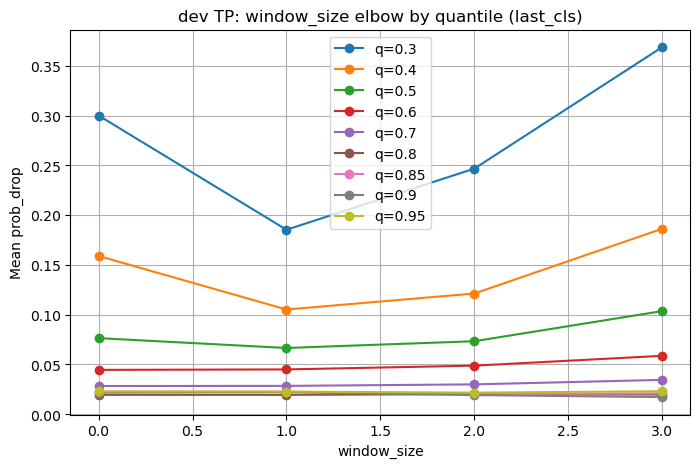

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_window_elbow_by_quantile_last_cls.png


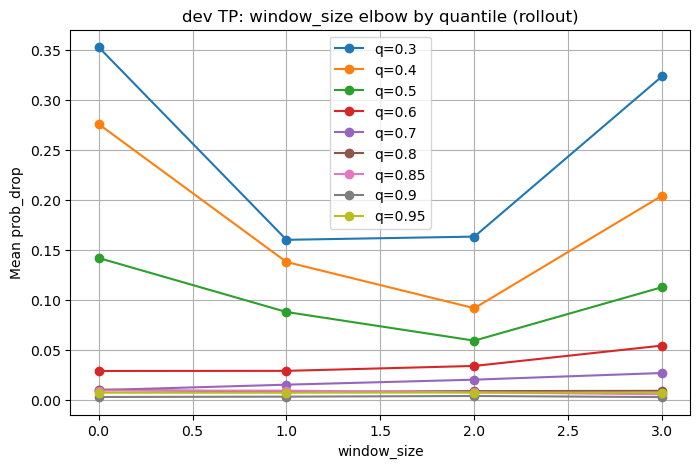

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_window_elbow_by_quantile_rollout.png


In [26]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 5))
    
    for quantile in sorted(method_df["quantile"].unique()):
        subset = method_df[
            method_df["quantile"] == quantile
        ].sort_values("window_size")
        
        plt.plot(
            subset["window_size"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"q={quantile}"
        )
    
    plt.xlabel("window_size")
    plt.ylabel("Mean prob_drop")
    plt.title(f"dev TP: window_size elbow by quantile ({method})")
    plt.grid(True)
    plt.legend()
    
    plot_path = dev_output_dir / f"attention_dev_window_elbow_by_quantile_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

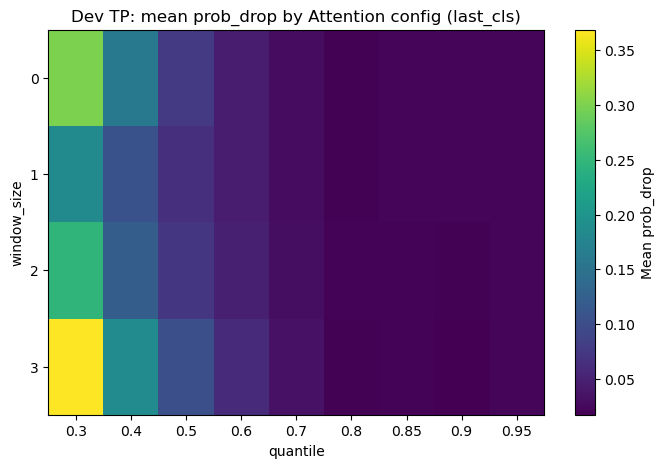

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_find_config_heatmap_last_cls.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,0.300063,0.158977,0.076464,0.044583,0.028357,0.019480,0.022703,0.021796,0.022878
1,0.185337,0.105221,0.066584,0.045046,0.028513,0.019461,0.022630,0.022111,0.022755
2,0.246754,0.121302,0.073373,0.048838,0.030020,0.020258,0.020069,0.019278,0.021713
3,0.368820,0.186348,0.103646,0.058704,0.034557,0.019837,0.021096,0.017260,0.023132


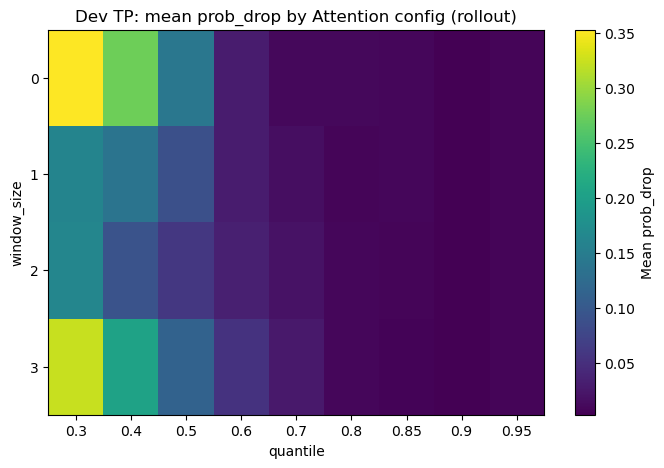

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_find_config_heatmap_rollout.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,0.353042,0.275997,0.141957,0.028856,0.009696,0.010182,0.009260,0.002819,0.007105
1,0.160124,0.137934,0.087881,0.028964,0.015131,0.007818,0.009159,0.003161,0.007087
2,0.163334,0.091695,0.059205,0.033895,0.020149,0.008696,0.007426,0.003813,0.007276
3,0.323902,0.204429,0.112780,0.054281,0.026831,0.008989,0.005543,0.002722,0.007225


In [27]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    heatmap_data = method_df.pivot(
        index="window_size",
        columns="quantile",
        values="mean_prob_drop"
    )
    
    plt.figure(figsize=(8, 5))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label="Mean prob_drop")
    
    plt.xticks(
        ticks=np.arange(len(heatmap_data.columns)),
        labels=heatmap_data.columns
    )
    plt.yticks(
        ticks=np.arange(len(heatmap_data.index)),
        labels=heatmap_data.index
    )
    
    plt.xlabel("quantile")
    plt.ylabel("window_size")
    plt.title(f"Dev TP: mean prob_drop by Attention config ({method})")
    
    plot_path = dev_output_dir / f"attention_dev_find_config_heatmap_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)
    display(heatmap_data)

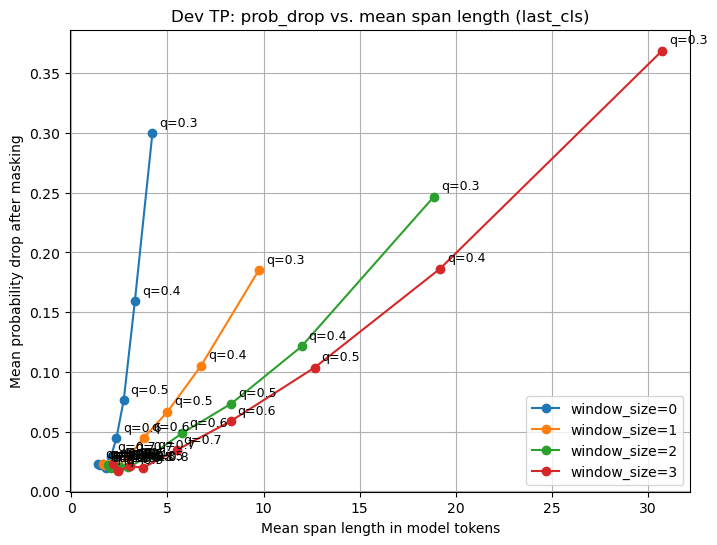

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_prob_drop_vs_mean_span_len_last_cls.png


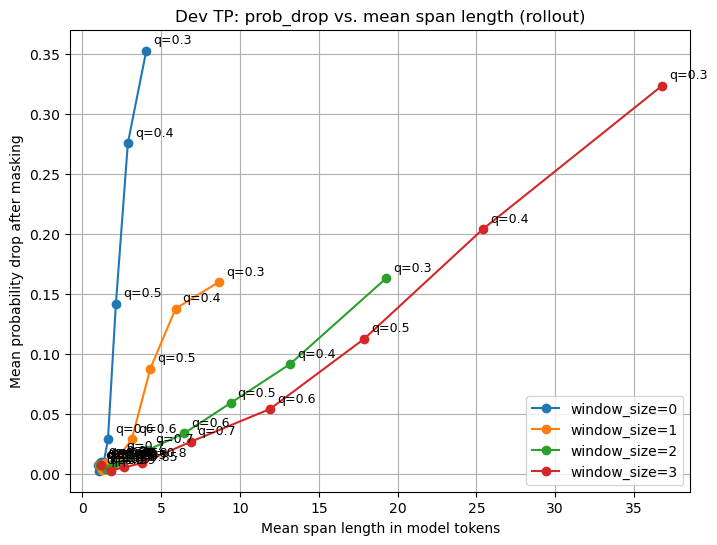

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_prob_drop_vs_mean_span_len_rollout.png


In [28]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_span_len_tokens"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_span_len_tokens"], row["mean_prob_drop"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean span length in model tokens")
    plt.ylabel("Mean probability drop after masking")
    plt.title(f"Dev TP: prob_drop vs. mean span length ({method})")
    plt.grid(True)
    plt.legend()
    
    plot_path = dev_output_dir / f"attention_dev_prob_drop_vs_mean_span_len_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

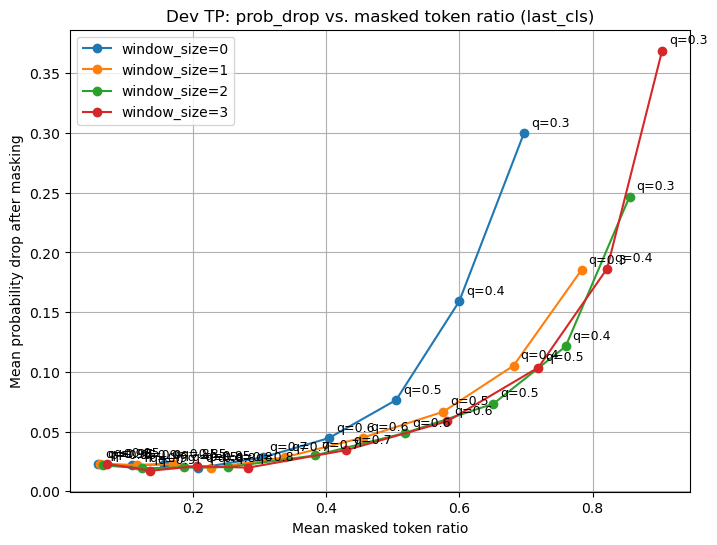

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_prob_drop_vs_masked_token_ratio_last_cls.png


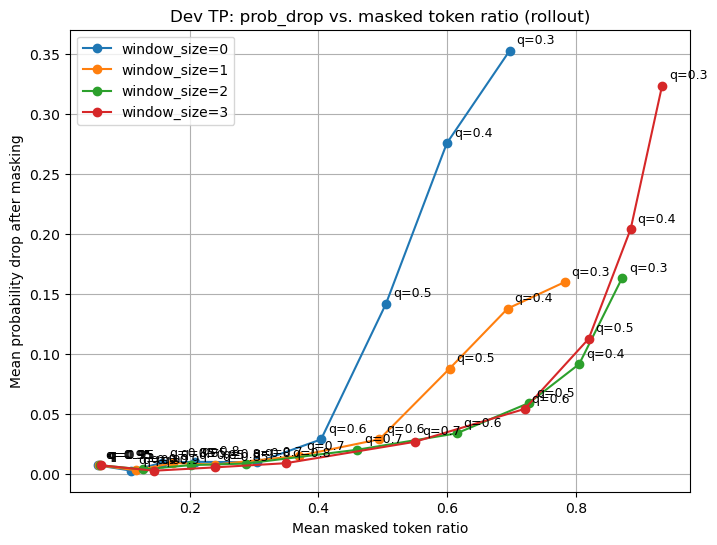

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_prob_drop_vs_masked_token_ratio_rollout.png


In [29]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_masked_token_ratio"],
            subset["mean_prob_drop"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Mean probability drop after masking")
    plt.title(f"Dev TP: prob_drop vs. masked token ratio ({method})")
    plt.grid(True)
    plt.legend()
    
    plot_path = dev_output_dir / f"attention_dev_prob_drop_vs_masked_token_ratio_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

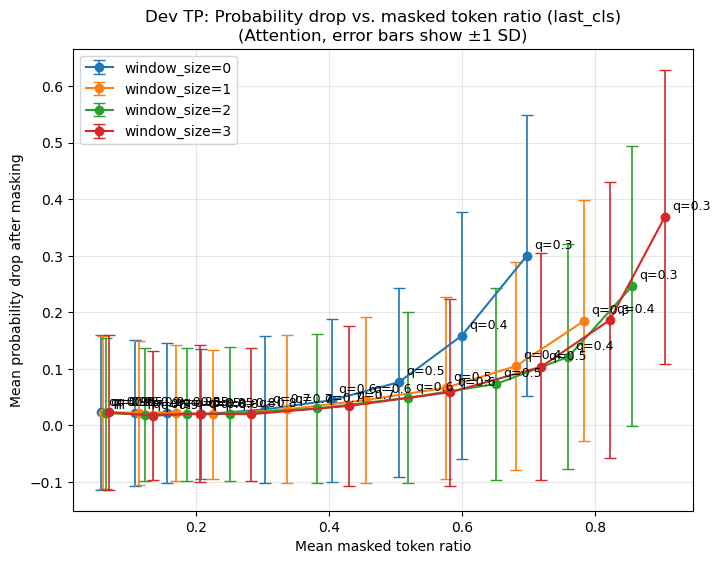

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_prob_drop_vs_masked_token_ratio_with_std_last_cls.png


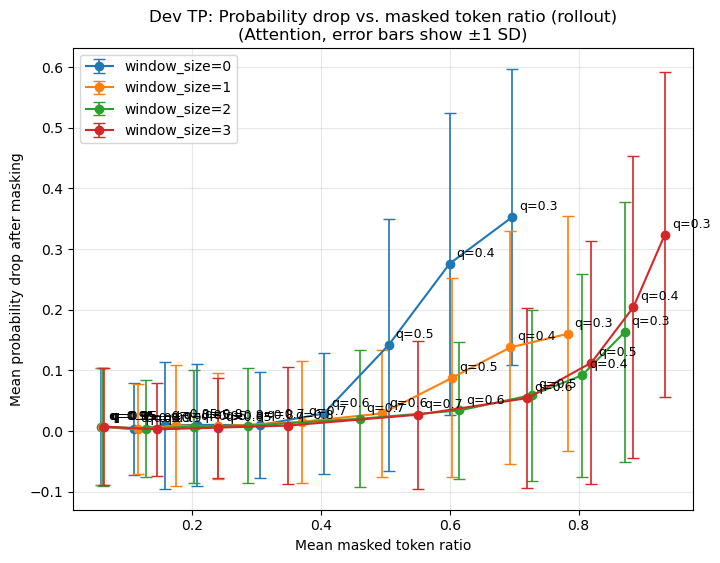

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_prob_drop_vs_masked_token_ratio_with_std_rollout.png


In [30]:
for method in sorted(dev_config_summary["attention_method"].unique()):

    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
    
        plt.errorbar(
            subset["mean_masked_token_ratio"],
            subset["mean_prob_drop"],
            yerr=subset["std_prob_drop"],
            marker="o",
            linestyle="-",
            capsize=4,
            elinewidth=1.2,
            label=f"window_size={window_size}"
        )
    
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (
                    row["mean_masked_token_ratio"],
                    row["mean_prob_drop"]
                ),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Mean probability drop after masking")
    plt.title(
        f"Dev TP: Probability drop vs. masked token ratio ({method})\n"
        "(Attention, error bars show ±1 SD)"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plot_path = (
        dev_output_dir
        / f"attention_dev_prob_drop_vs_masked_token_ratio_with_std_{method}.png"
    )
    
    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    
    print("Saved plot:", plot_path)

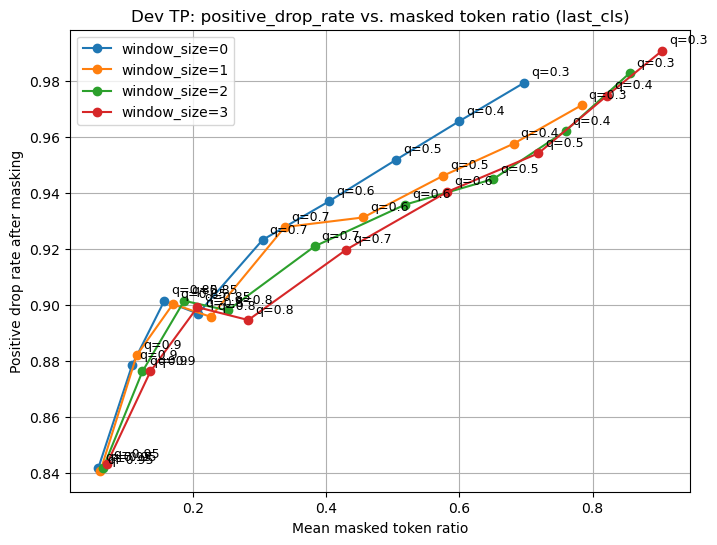

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_positive_drop_rate_vs_masked_token_ratio_last_cls.png


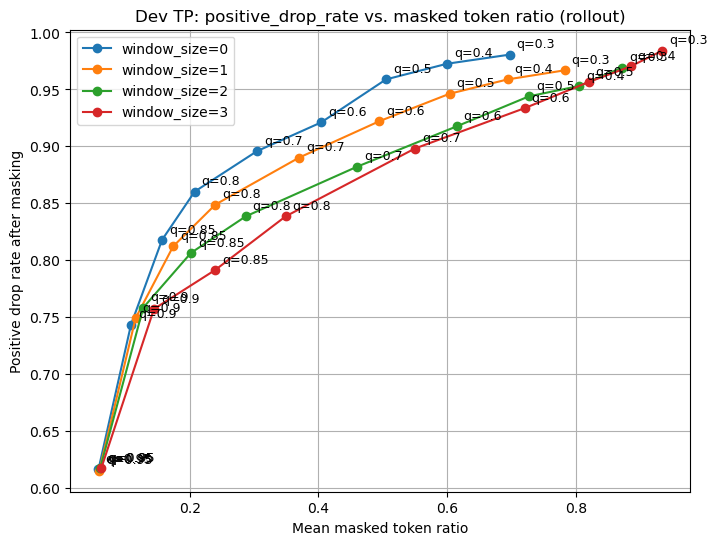

Saved plot: attention_results_aopc/dev_config_selection/attention_dev_positive_drop_rate_vs_masked_token_ratio_rollout.png


In [31]:
for method in sorted(dev_config_summary["attention_method"].unique()):
    method_df = dev_config_summary[
        dev_config_summary["attention_method"] == method
    ].copy()
    
    plt.figure(figsize=(8, 6))
    
    for window_size in sorted(method_df["window_size"].unique()):
        subset = method_df[
            method_df["window_size"] == window_size
        ].sort_values("quantile")
        
        plt.plot(
            subset["mean_masked_token_ratio"],
            subset["positive_drop_rate"],
            marker="o",
            label=f"window_size={window_size}"
        )
        
        for _, row in subset.iterrows():
            plt.annotate(
                f"q={row['quantile']}",
                (row["mean_masked_token_ratio"], row["positive_drop_rate"]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=9
            )
    
    plt.xlabel("Mean masked token ratio")
    plt.ylabel("Positive drop rate after masking")
    plt.title(f"Dev TP: positive_drop_rate vs. masked token ratio ({method})")
    plt.grid(True)
    plt.legend()
    
    plot_path = dev_output_dir / f"attention_dev_positive_drop_rate_vs_masked_token_ratio_{method}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print("Saved plot:", plot_path)

In [ ]:
# Provisional config from attention validation results.
# This is not the final config yet.
# It is only used for qualitative inspection before word-boundary post-processing.

BEST_ATTENTION_METHOD = "rollout"
BEST_QUANTILE = 0.4
BEST_WINDOW_SIZE = 0

selected_config_summary = dev_config_summary[
    (dev_config_summary["attention_method"] == BEST_ATTENTION_METHOD) &
    (dev_config_summary["quantile"] == BEST_QUANTILE) &
    (dev_config_summary["window_size"] == BEST_WINDOW_SIZE)
]

display(selected_config_summary)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,...,median_masked_token_ratio,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_attention,mean_span_score_mean_attention,prob_drop_per_masked_token,prob_drop_per_masked_ratio
37,rollout,0,0.4,873,0.275997,0.220642,0.249166,0.972509,0.867125,0.691867,...,0.6,16826,2.880423,2.0,10.162427,6.0,0.041818,0.014692,0.004971,0.460219


## Selected attention configuration

The attention-based method was tuned on validation true positives, i.e., arguments that were labeled as inappropriate and also predicted as inappropriate by the document-level classifier. This keeps the configuration selection comparable to the other span localization methods.

The evaluated configurations varied:

- `attention_method ∈ {last_cls, rollout}`
- `quantile ∈ {0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95}`
- `window_size ∈ {0, 1, 2, 3}`

In this notebook, `window_size` is a merge-gap parameter for attention-based spans. It does not add a symmetric token window around selected tokens. Instead, it controls how many unselected tokens may lie between selected tokens for them to be merged into one span.

The final configuration was selected based on the validation trade-off between probability drop and masked token ratio. The selected setting is:

- `attention_method = rollout`
- `quantile = 0.4`
- `window_size = 0`

This setting produces very short spans while still yielding a positive average probability drop after masking. However, because attention weights are not guaranteed to be faithful explanations, the method is interpreted as a candidate-generation approach validated through perturbation.

In [ ]:
def show_attention_example(result_df, index=0):
    """Display one attention result with highlighted masked spans."""
    row = result_df.iloc[index]
    
    spans = json.loads(row["merged_spans_json"])
    marked = highlight_spans(row["text"], spans)
    
    display(HTML(f"""
    <div style="
        border:1px solid #ccc;
        border-radius:8px;
        padding:14px;
        margin:12px 0;
        font-family:Arial, sans-serif;
        line-height:1.45;
    ">
        <b>global_row_id:</b> {html.escape(str(row["global_row_id"]))}<br>
        <b>post_id:</b> {html.escape(str(row["post_id"]))}<br>
        <b>split:</b> {html.escape(str(row["split"]))}<br>
        <b>confusion_type:</b> {html.escape(str(row["confusion_type"]))}<br>
        <b>issue:</b> {html.escape(str(row["issue"]))}<br>
        <b>method:</b> {html.escape(str(row["attention_method"]))} |
        <b>quantile:</b> {row["quantile"]} |
        <b>window_size:</b> {row["window_size"]}<br>
        <b>merged_spans:</b> {html.escape(str(row["merged_span_texts"]))}<br>
        <b>p_original:</b> {float(row["p_inappropriate_original"]):.4f}<br>
        <b>p_masked:</b> {float(row["p_inappropriate_masked"]):.4f}<br>
        <b>prob_drop:</b> {float(row["prob_drop"]):.4f}<br>
        <b>masked_token_ratio:</b> {float(row["masked_token_ratio"]):.4f}<br>
        <hr>
        <p>{marked}</p>
    </div>
    """))

In [ ]:
dev_best_examples = dev_tp_argument_df[
    (dev_tp_argument_df["attention_method"] == BEST_ATTENTION_METHOD) &
    (dev_tp_argument_df["quantile"] == BEST_QUANTILE) &
    (dev_tp_argument_df["window_size"] == BEST_WINDOW_SIZE) &
    (dev_tp_argument_df["error"].isna())
].copy()

print("Dev examples for provisional config:", len(dev_best_examples))
display(
    dev_best_examples[
        [
            "global_row_id",
            "post_id",
            "prob_drop",
            "masked_token_ratio",
            "merged_span_texts"
        ]
    ].head()
)

Dev examples for provisional raw config: 873


,global_row_id,post_id,prob_drop,masked_token_ratio,merged_span_texts
40,0,1,0.029803,0.595238,"[people cant be forced to wear, uniforms, i, h..."
112,1,2,0.612050,0.600000,"[That form of, degrades this forum, and will, ..."
184,3,4,0.012809,0.593750,"[No I wouldn', in my spouse., the girl that i,..."
256,4,5,0.014057,0.594595,"[TV is, . Except for, . That's an alright, ., ..."
328,5,6,0.013503,0.600000,"[I love, , I, in them. They also, your literat..."


In [ ]:
tmp_top = (
    dev_best_examples
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_top))):
    show_attention_example(tmp_top, index=i)

# Saving Results and Summary

In [ ]:
def run_final_attention_on_split(df, split_name):
    """
    Run the selected Attention configuration on one split.
    
    The final configuration is fixed and not re-tuned per split.
    """
    positions = list(range(len(df)))
    
    results = run_attention_config_on_indices(
        df=df,
        matrix_positions=positions,
        attention_methods=[BEST_ATTENTION_METHOD],
        quantile_values=[BEST_QUANTILE],
        window_size_values=[BEST_WINDOW_SIZE],
        mask_token=MASK_TOKEN
    )
    
    argument_df = build_argument_level_df(results)
    span_df = build_span_level_df(results)
    
    print(f"{split_name} argument level:", argument_df.shape)
    print(f"{split_name} span level:", span_df.shape)
    
    return results, argument_df, span_df


# train_results, train_argument_df, train_span_df = run_final_attention_on_split(
#     train_df,
#     "train"
# )

# val_results, val_argument_df, val_span_df = run_final_attention_on_split(
#     val_df,
#     "validation"
# )

test_results, test_argument_df, test_span_df = run_final_attention_on_split(
    test_df,
    "test"
)

Building attention spans:   0%|          | 0/438 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

test raw argument level: (438, 43)
test raw span level: (8859, 36)


In [ ]:
final_argument_df = pd.concat(
    [test_argument_df],
    ignore_index=True
)

final_span_df = pd.concat(
    [test_span_df],
    ignore_index=True
)

display(final_argument_df.head())
display(final_span_df.head())

print("Final argument-level rows:", len(final_argument_df))
print("Final span-level rows:", len(final_span_df))

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_texts,merged_span_token_start_indices,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_tokens_json,merged_spans_json,text,masked_text,error
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,0.892726,FN,False,True,...,"[students should, they, and feel, their clothes]","[1, 5, 7, 11]","[2, 5, 8, 12]","[0, 26, 36, 56]","[15, 30, 44, 69]","[""▁students"", ""▁should"", ""▁they"", ""▁and"", ""▁fe...","[{""char_start"": 0, ""char_end"": 15, ""token_star...",students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...,None
1,1754,test,8,Tv is better than books:,1,LABEL_1,0.997475,TP,True,False,...,"[I thick that book are, is it is, i, you in a,...","[1, 9, 13, 16, 24]","[5, 11, 13, 18, 27]","[0, 37, 53, 63, 91]","[21, 45, 54, 71, 112]","[""▁I"", ""▁thick"", ""▁that"", ""▁book"", ""▁are"", ""▁i...","[{""char_start"": 0, ""char_end"": 21, ""token_star...",I thick that book are better than TV is it is ...,[MASK] [MASK] [MASK] [MASK] [MASK] better than...,None
2,1755,test,9,Tv is better than books:,1,LABEL_1,0.998255,TP,True,False,...,"[Books enlighten the soul. Books, ', the moral...","[1, 8, 11, 15, 18, 21, 25, 28, 33, 35, 38, 41,...","[6, 8, 13, 15, 18, 23, 26, 30, 33, 36, 38, 42,...","[0, 35, 46, 68, 82, 96, 117, 129, 159, 169, 18...","[31, 36, 59, 69, 85, 107, 123, 143, 160, 174, ...","[""▁Books"", ""▁enlighten"", ""▁the"", ""▁soul"", ""."",...","[{""char_start"": 0, ""char_end"": 31, ""token_star...",Books enlighten the soul. Books don't destroy ...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] don[...,None
3,1756,test,12,India has the potential to lead the world:,1,LABEL_1,0.995627,TP,True,False,...,"[india is is, but a, and, should be a, developer]","[1, 6, 10, 12, 16]","[3, 7, 10, 14, 16]","[0, 25, 45, 56, 74]","[11, 30, 48, 67, 83]","[""▁india"", ""▁is"", ""▁is"", ""▁but"", ""▁a"", ""▁and"",...","[{""char_start"": 0, ""char_end"": 11, ""token_star...",india is is good adopter but a bad developer a...,[MASK] [MASK] [MASK] good adopter [MASK] [MASK...,None
4,1757,test,15,Is it better to have a lousy father or to be f...,0,LABEL_0,0.993661,TN,False,False,...,"[Honestly, I'd, be, ,, that, is, , albeit a lo...","[1, 7, 11, 14, 17, 22, 27, 33, 41, 48, 50, 55,...","[5, 7, 11, 14, 17, 25, 30, 35, 41, 48, 53, 58,...","[0, 21, 45, 58, 74, 99, 119, 143, 186, 224, 23...","[13, 23, 46, 62, 76, 115, 131, 155, 189, 227, ...","[""▁Honestly"", "","", ""▁I"", ""'"", ""d"", ""▁be"", "","",...","[{""char_start"": 0, ""char_end"": 13, ""token_star...","Honestly, I'd rather be completely fatherless,...",[MASK] [MASK] [MASK] [MASK] [MASK] rather [MAS...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,span_score_max_attention,p_inappropriate_original,p_inappropriate_masked,prob_drop,n_model_tokens,n_selected_tokens,selected_token_ratio,masked_token_ratio,text,masked_text
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.105267,0.107274,0.910977,-0.803703,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...
1,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.084161,0.107274,0.910977,-0.803703,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...
2,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.134787,0.107274,0.910977,-0.803703,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...
3,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.125380,0.107274,0.910977,-0.803703,12,7,0.583333,0.583333,students should wear what they like and feel f...,[MASK] [MASK] wear what [MASK] like [MASK] [MA...
4,1754,test,8,Tv is better than books:,1,LABEL_1,TP,True,False,False,...,0.044088,0.997475,0.972826,0.024650,27,16,0.592593,0.592593,I thick that book are better than TV is it is ...,[MASK] [MASK] [MASK] [MASK] [MASK] better than...


Final argument-level rows: 438
Final span-level rows: 8859


In [39]:
final_argument_df_valid = final_argument_df[
    final_argument_df["error"].isna()
].copy()

overall_summary = (
    final_argument_df_valid
    .groupby(["split", "attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

confusion_summary = (
    final_argument_df_valid
    .groupby(["split", "confusion_type"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values(["split", "confusion_type"])
)

display(overall_summary)
display(confusion_summary)

,split,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,test,rollout,0,0.4,438,-0.069014,0.009295,0.447021,0.563927,0.495434,0.378995,0.590804,0.659818,20.226027,57.97032,0.599908


,split,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,test,FN,39,-0.502262,-0.425041,0.216775,0.000000,0.049638,0.551901,22.743590,65.358974,0.599475
1,test,FP,71,0.270124,0.158195,0.263937,0.929577,0.971585,0.701461,18.154930,51.408451,0.600268
2,test,TN,142,-0.520877,-0.432638,0.225277,0.014085,0.037216,0.558093,22.894366,65.957746,0.599689
3,test,TP,186,0.237344,0.134223,0.250078,0.962366,0.981555,0.744211,18.451613,52.827957,0.600029


In [40]:
test_argument_df_valid = test_argument_df[
    test_argument_df["error"].isna()
].copy()

test_overall_summary = (
    test_argument_df_valid
    .groupby(["attention_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
)

test_confusion_summary = (
    test_argument_df_valid
    .groupby("confusion_type")
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
    )
    .reset_index()
    .sort_values("confusion_type")
)

display(test_overall_summary)
display(test_confusion_summary)

,attention_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,rollout,0,0.4,438,-0.069014,0.009295,0.447021,0.563927,0.495434,0.378995,0.590804,0.659818,20.226027,57.97032,0.599908


,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio
0,FN,39,-0.502262,-0.425041,0.216775,0.000000,0.049638,0.551901,22.743590,65.358974,0.599475
1,FP,71,0.270124,0.158195,0.263937,0.929577,0.971585,0.701461,18.154930,51.408451,0.600268
2,TN,142,-0.520877,-0.432638,0.225277,0.014085,0.037216,0.558093,22.894366,65.957746,0.599689
3,TP,186,0.237344,0.134223,0.250078,0.962366,0.981555,0.744211,18.451613,52.827957,0.600029


In [ ]:
final_output_dir = OUTPUT_DIR / "attention_results_final" 
final_output_dir.mkdir(parents=True, exist_ok=True)

argument_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.csv"
)

span_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_span_level.csv"
)

overall_summary_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_overall_summary.csv"
)

confusion_summary_csv_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_confusion_summary.csv"
)

test_summary_csv_path = final_output_dir / (
    f"attention_final_test_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_summary.csv"
)

jsonl_path = final_output_dir / (
    f"attention_final_all_splits_{BEST_ATTENTION_METHOD}"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.jsonl"
)

final_argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
final_span_df.to_csv(span_csv_path, index=False, encoding="utf-8")
overall_summary.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")
confusion_summary.to_csv(confusion_summary_csv_path, index=False, encoding="utf-8")
test_overall_summary.to_csv(test_summary_csv_path, index=False, encoding="utf-8")

all_results = test_results

with open(jsonl_path, "w", encoding="utf-8") as f:
    for result in all_results:
        safe_result = make_json_serializable(result)
        f.write(json.dumps(safe_result, ensure_ascii=False) + "\n")

print("Saved:")
print(argument_csv_path)
print(span_csv_path)
print(overall_summary_csv_path)
print(confusion_summary_csv_path)
print(test_summary_csv_path)
print(jsonl_path)

Saved:
attention_results_aopc/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_argument_level.csv
attention_results_aopc/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_span_level.csv
attention_results_aopc/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_overall_summary.csv
attention_results_aopc/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_confusion_summary.csv
attention_results_aopc/attention_results_final/attention_final_test_rollout_q0.4_window0_summary.csv
attention_results_aopc/attention_results_final/attention_final_all_splits_rollout_q0.4_window0_argument_level.jsonl


In [43]:
# Best test examples by probability drop
tmp = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp))):
    show_attention_example(tmp, index=i)

In [44]:
# Test examples with the smallest or negative probability drops
tmp_low = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=True)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_low))):
    show_attention_example(tmp_low, index=i)

In [66]:
test_tp_positions = test_df.index[
    test_df["confusion_type"] == "TP"
].tolist()

print("Test examples:", len(test_df))
print("Test true positives:", len(test_tp_positions))

test_attention_cache = precompute_attention_cache(
    df=test_df,
    matrix_positions=test_tp_positions,
    attention_methods=[BEST_ATTENTION_METHOD],
    cache_path=TEST_ATTENTION_CACHE_PATH,
    overwrite=OVERWRITE_ATTENTION_CACHE
)

Test examples: 438
Test true positives: 186


Precomputing attention cache:   0%|          | 0/186 [00:00<?, ?it/s]

Saved attention cache to: attention_results_aopc/cache/attention_cache_test_tp.json


In [ ]:
test_aopc_df = run_attention_aopc_on_indices(
    df=test_df,
    matrix_positions=test_tp_positions,
    attention_methods=[BEST_ATTENTION_METHOD],
    fractions=AOPC_FRACTIONS,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    mask_token=MASK_TOKEN,
    attention_cache=test_attention_cache,
)

test_aopc_step_df, test_aopc_curve_summary, test_aopc_per_argument, test_aopc_global_summary = summarize_attention_aopc_results(
    test_aopc_df
)

display(test_aopc_curve_summary)
display(test_aopc_global_summary)

save_aopc_outputs(
    aopc_df=test_aopc_df,
    step_df=test_aopc_step_df,
    curve_summary=test_aopc_curve_summary,
    per_argument_aopc=test_aopc_per_argument,
    global_summary=test_aopc_global_summary,
    output_dir=AOPC_OUTPUT_DIR,
    prefix="attention_aopc_test_tp_attention"
)

plot_attention_aopc_curve(
    curve_summary=test_aopc_curve_summary,
    output_dir=AOPC_OUTPUT_DIR,
    filename="attention_aopc_test_tp_curve.png",
    title="Test TP: Attention AOPC"
)

plot_attention_aopc_global_bar(
    global_summary=test_aopc_global_summary,
    output_dir=AOPC_OUTPUT_DIR,
    filename="attention_aopc_test_tp_global_bar.png",
    title="Test TP: Global Attention AOPC"
)

AOPC Attention (raw_attention):   0%|          | 0/186 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/640 [00:00<?, ?it/s]

,aopc_variant,attention_method,ranking_method,perturbation_fraction,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_masked_token_ratio,median_masked_token_ratio,mean_selected_token_ratio,mean_top_k_tokens,mean_total_masked_tokens,mean_total_masked_chars,mean_n_merged_spans,fallback_rate
0,raw_attention,last_cls,attention,0.01,186,0.014064,0.000213,0.105409,0.801075,0.981555,0.967490,0.023032,0.016065,0.023032,1.413978,1.413978,4.069892,1.263441,0.0
1,raw_attention,last_cls,attention,0.05,186,0.011584,0.000525,0.110357,0.827957,0.981555,0.969971,0.058111,0.055556,0.058111,4.849462,4.849462,12.973118,3.392473,0.0
2,raw_attention,last_cls,attention,0.10,186,0.017006,0.000876,0.121466,0.838710,0.981555,0.964549,0.108701,0.104938,0.108701,9.241935,9.241935,23.983871,6.118280,0.0
3,raw_attention,last_cls,attention,0.20,186,0.009608,0.001598,0.120960,0.860215,0.981555,0.971947,0.208118,0.204463,0.208118,18.016129,18.016129,50.983871,10.274194,0.0
4,raw_attention,last_cls,attention,0.50,186,0.057548,0.010759,0.152849,0.940860,0.981555,0.924007,0.504578,0.500000,0.504578,44.263441,44.263441,158.311828,16.155914,0.0
5,raw_attention,last_cls,random,0.01,186,0.000022,0.000002,0.030277,0.516129,0.981555,0.981533,0.023032,0.016065,0.023032,1.413978,1.413978,5.282258,1.410215,0.0
6,raw_attention,last_cls,random,0.05,186,-0.005098,0.000110,0.043205,0.693548,0.981555,0.986653,0.058111,0.055556,0.058111,4.849462,4.849462,18.046774,4.635484,0.0
7,raw_attention,last_cls,random,0.10,186,-0.002655,0.000226,0.046762,0.741935,0.981555,0.984210,0.108701,0.104938,0.108701,9.241935,9.241935,34.684409,8.358065,0.0
8,raw_attention,last_cls,random,0.20,186,-0.003456,0.000436,0.067491,0.758065,0.981555,0.985010,0.208112,0.204463,0.208118,18.016129,18.015591,69.333871,14.547312,0.0
9,raw_attention,last_cls,random,0.50,186,-0.002422,0.002405,0.066744,0.876344,0.981555,0.983977,0.504572,0.500000,0.504578,44.263441,44.262903,181.473656,22.477957,0.0


,aopc_variant,attention_method,ranking_method,n_arguments,aopc_mean_prob_drop,aopc_median_prob_drop,aopc_std_prob_drop,mean_positive_steps_rate,mean_masked_token_ratio,mean_max_masked_token_ratio,mean_total_masked_tokens,fallback_rate
0,raw_attention,last_cls,attention,186,0.021962,0.003167,0.080667,0.853763,0.180508,0.504578,15.556989,0.0
1,raw_attention,last_cls,random,186,-0.002722,0.000753,0.044844,0.717204,0.180506,0.504572,15.556774,0.0


Saved:
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_test_tp_raw_attention_raw.csv
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_test_tp_raw_attention_step_summary.csv
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_test_tp_raw_attention_curve_summary.csv
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_test_tp_raw_attention_per_argument.csv
attention_results_aopc/aopc_ranking_evaluation/attention_aopc_test_tp_raw_attention_global_summary.csv
